# Phase 1: Project Setup & Dataset Understanding
**Project:** Customer Churn Intelligence  
**Dataset:** IBM Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)  
**Objective:** Perform initial exploratory inspection, understand every attribute, profile the target distribution, and establish a foundational data profile without applying machine learning models or destructive transformations.

---
### Dataset Background
The dataset represents telecommunications customer profiles from IBM Sample Data Sets.
- **Total records:** 7,043 customers
- **Total attributes:** 21 columns
- **Target variable:** `Churn` (Indicates whether the customer left within the last month)


## Step 1 — Imports
We import standard data exploration libraries: `pandas`, `numpy`, and `matplotlib`.  
*Note: No ML libraries are imported or used in this phase.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set display options for comprehensive inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


## Step 2 — Load Dataset
Loading the raw, unmodified CSV directly from `../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv`.  
*Rule:* We preserve the original raw dataset intact.

In [2]:
raw_data_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(raw_data_path)
print(f"Dataset successfully loaded from: {raw_data_path}")


Dataset successfully loaded from: ../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv


## Step 3 — Basic Inspection
Examining dataset dimensions, first few rows, last few rows, schema information, and descriptive statistics.

In [3]:
# Dimensions of the dataset
print(f"Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")
df.shape


Shape: (7043, 21) (Rows: 7043, Columns: 21)


(7043, 21)

In [4]:
# First 5 records
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Last 5 records
df.tail()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
# Data schema, non-null counts, and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
# Summary statistics for all columns (numerical and categorical)
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 4 — Understand the Target Variable (`Churn`)
Analyzing class distribution, frequency, and relative percentages. We compute the exact distribution from the data rather than hardcoding assumptions.

In [8]:
# Raw counts of Churn
churn_counts = df["Churn"].value_counts()
churn_counts


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
# Percentage distribution of Churn
churn_pct = df["Churn"].value_counts(normalize=True) * 100
churn_pct.round(2)


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

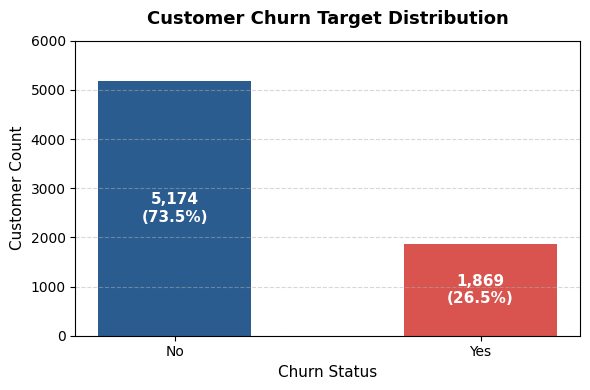

In [10]:
# Visualizing class distribution
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(churn_counts.index, churn_counts.values, color=['#2b5c8f', '#d9534f'], width=0.5)

for bar in bars:
    height = bar.get_height()
    pct = (height / len(df)) * 100
    ax.annotate(f'{height:,}\n({pct:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height / 2),
                xytext=(0, 0), textcoords="offset points",
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

ax.set_title("Customer Churn Target Distribution", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Churn Status", fontsize=11)
ax.set_ylabel("Customer Count", fontsize=11)
ax.set_ylim(0, 6000)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Step 5 — Separate Column Types
Categorizing attributes based on domain meaning:
1. **Identifier:** `customerID`
2. **Target:** `Churn`
3. **Numerical Attributes:** `tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen` *(stored as int 0/1)*
4. **Categorical Attributes:** Demographics, account contract terms, and subscription services.

In [11]:
# Note: TotalCharges is currently loaded as object (string) due to whitespace values.
# In domain reality, it is numerical.
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
id_col = ["customerID"]
target_col = ["Churn"]

categorical_cols = [col for col in df.columns if col not in numerical_cols + id_col + target_col]

print(f"Identifier Column ({len(id_col)}): {id_col}")
print(f"Target Column ({len(target_col)}): {target_col}")
print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")


Identifier Column (1): ['customerID']
Target Column (1): ['Churn']
Numerical Columns (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical Columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
# Check whitespace strings in TotalCharges
whitespace_totalcharges = df[df["TotalCharges"].str.strip() == ""]
print(f"Rows with blank TotalCharges: {len(whitespace_totalcharges)}")
whitespace_totalcharges[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head()


Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No


In [13]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows in raw data: {duplicate_count}")


Number of duplicate rows in raw data: 0


## Phase 1 Final Output: Data Profile Summary
Below is the synthesized data profile based on our exploration:

| Item | Result |
| :--- | :--- |
| **Rows** | **7,043** |
| **Columns** | **21** |
| **Target Variable** | **Churn** |
| **Numerical Columns** | `tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen` |
| **Categorical Columns** | 16 features (`gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `Churn`) |
| **Identifier Column** | `customerID` (7,043 unique alphanumeric IDs) |
| **Missing Values** | 11 rows in `TotalCharges` contain blank spaces (`" "`) where `tenure == 0` |
| **Duplicate Rows** | 0 duplicates |
| **Class Distribution** | **No Churn:** 5,174 (73.46%), **Churn:** 1,869 (26.54%) |

### Next Steps for Phase 2:
In Phase 2, we will address data cleaning:
- Dropping `customerID`
- Converting `TotalCharges` to numeric and handling the 11 zero-tenure records
- Checking categorical consistency
- Mapping `Churn` to binary integers (`Yes` -> 1, `No` -> 0)
- Saving the clean dataset to `../data/processed/telco_churn_clean.csv`
